# Model 1 — Time-Varying Parameter Factor Attribution via Kalman Filter

Replaces the static 3-/4-factor OLS in `python_files.ipynb` with a Kalman filter
where **alpha and all betas drift as random walks**. This lets us see *when* the
manager generated alpha and *how* factor tilts shifted over time.

**State:** `[alpha, beta_mkt, beta_smb, beta_hml, beta_mom]`  
**Transition:** `x_t = x_{t-1} + eta_t` (random walk)  
**Observation:** `r_t - rf_t = alpha_t + betas_t' * factors_t + eps_t`  
**Data:** `combined_monthly.csv` — full window (2014-10 to 2025-06, ~129 months)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tvp_kalman_filter import KalmanFilter
import statsmodels.api as sm

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 1. Load and Prepare Data

In [2]:
DATA_PATH = "../data/engineered_data/combined_monthly.csv"

FACTOR_COLS = ["Mkt_RF", "SMB", "HML", "Mom"]

df = pd.read_csv(DATA_PATH, parse_dates=["month"])
df = df.set_index("month").sort_index()

# Excess returns (all already in decimal)
df["excess_ret"] = df["fund_ret"] - df["RF"]

# Drop rows where fund_ret or any factor is missing
cols_needed = ["excess_ret"] + FACTOR_COLS
df_model = df[cols_needed].dropna()

y = df_model["excess_ret"].values
X = df_model[FACTOR_COLS].values
dates = df_model.index

n_obs = len(y)
n_factors = X.shape[1]
n_states = 1 + n_factors  # alpha + betas

print(f"Observations: {n_obs}  |  Factors: {n_factors}  |  States: {n_states}")
print(f"Window: {dates[0].strftime('%Y-%m')} to {dates[-1].strftime('%Y-%m')}")
df_model.describe().round(4)

Observations: 129  |  Factors: 4  |  States: 5
Window: 2014-10 to 2025-06


,excess_ret,Mkt_RF,SMB,HML,Mom
count,129.0000,129.0000,129.0000,129.0000,129.0000
mean,0.0065,0.0048,-0.0007,0.0020,0.0055
std,0.0633,0.0426,0.0143,0.0267,0.0258
min,-0.1572,-0.1392,-0.0321,-0.0735,-0.1231
25%,-0.0266,-0.0206,-0.0121,-0.0145,-0.0068
50%,0.0116,0.0077,0.0004,-0.0005,0.0076
75%,0.0393,0.0325,0.0093,0.0185,0.0205
max,0.1949,0.1458,0.0338,0.1270,0.0721


## 2. Static OLS Baseline

For comparison — the model this Kalman filter generalizes.

In [3]:
X_ols = sm.add_constant(X)
ols_model = sm.OLS(y, X_ols).fit()
print(ols_model.summary())

ols_alpha_monthly = ols_model.params[0]
ols_alpha_annual = (1 + ols_alpha_monthly) ** 12 - 1
print(f"\nStatic OLS alpha: {ols_alpha_monthly:.4f}/mo  ({ols_alpha_annual:.2%}/yr)")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     168.5
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           3.89e-49
Time:                        13:10:22   Log-Likelihood:                 293.56
No. Observations:                 129   AIC:                            -577.1
Df Residuals:                     124   BIC:                            -562.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.002      0.682      0.4

## 3. Kalman Filter Setup

**Transition matrix:** Identity (random walk — parameters can drift each month).  
**Observation matrix:** Time-varying — row `[1, MktRF_t, SMB_t, HML_t, Mom_t]` at each `t`.  
**Initial state:** OLS estimates from first 12 months.  
**Noise covariances:** Estimated via EM.

In [4]:
# --- Build time-varying observation matrices ---
# Each obs matrix is (1, n_states): [1, factor_1, ..., factor_k]
obs_matrices = np.zeros((n_obs, 1, n_states))
obs_matrices[:, 0, 0] = 1.0          # intercept (alpha)
obs_matrices[:, 0, 1:] = X           # factor values

# --- Initial state from OLS on first 12 months ---
init_window = min(12, n_obs)
X_init = sm.add_constant(X[:init_window])
ols_init = sm.OLS(y[:init_window], X_init).fit()
initial_state = ols_init.params
initial_cov = np.diag(ols_init.bse ** 2) * 10  # inflate uncertainty

print("Initial state (from first 12-month OLS):")
for name, val in zip(["alpha"] + FACTOR_COLS, initial_state):
    print(f"  {name:>8s}: {val:+.4f}")

Initial state (from first 12-month OLS):
     alpha: +0.0018
    Mkt_RF: +0.5461
       SMB: +0.0100
       HML: +1.1313
       Mom: +0.9618


In [5]:
# --- Construct the Kalman filter ---
kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=n_states,
    transition_matrices=np.eye(n_states),       # random walk
    observation_matrices=obs_matrices,           # time-varying
    initial_state_mean=initial_state,
    initial_state_covariance=initial_cov,
    em_vars=[
        "transition_covariance",                 # Q
        "observation_covariance",                # R
    ],
)

# --- EM estimation of Q and R ---
observations = y.reshape(-1, 1)
kf = kf.em(observations, n_iter=20)

print("EM-estimated observation noise (R):")
print(f"  sigma_eps = {np.sqrt(kf.observation_covariance[0, 0]):.4f}")
print("\nEM-estimated state noise diagonal (sqrt of diag Q):")
for name, q in zip(["alpha"] + FACTOR_COLS, np.sqrt(np.diag(kf.transition_covariance))):
    print(f"  {name:>8s}: {q:.6f}")

EM-estimated observation noise (R):
  sigma_eps = 0.0236

EM-estimated state noise diagonal (sqrt of diag Q):
     alpha: 0.000010
    Mkt_RF: 0.084792
       SMB: 0.001296
       HML: 0.038540
       Mom: 0.001383


## 4. Filter and Smooth

In [6]:
# Forward pass (filtered) — what you'd know in real time
filtered_means, filtered_covs = kf.filter(observations)

# Forward-backward pass (smoothed) — best retrospective estimate
smoothed_means, smoothed_covs = kf.smooth(observations)

state_names = ["alpha"] + FACTOR_COLS

# Build DataFrames
df_filtered = pd.DataFrame(filtered_means, index=dates, columns=state_names)
df_smoothed = pd.DataFrame(smoothed_means, index=dates, columns=state_names)

# Standard errors (sqrt of diagonal of covariance at each t)
filtered_se = np.sqrt(np.array([np.diag(c) for c in filtered_covs]))
smoothed_se = np.sqrt(np.array([np.diag(c) for c in smoothed_covs]))
df_filtered_se = pd.DataFrame(filtered_se, index=dates, columns=state_names)
df_smoothed_se = pd.DataFrame(smoothed_se, index=dates, columns=state_names)

print("Smoothed state means (last 5 months):")
df_smoothed.tail()

Smoothed state means (last 5 months):


,alpha,Mkt_RF,SMB,HML,Mom
month,,,,,
2025-02-01,0.001148,1.068296,0.711560,-0.326343,0.026619
2025-03-01,0.001148,1.044862,0.711561,-0.320513,0.026620
2025-04-01,0.001148,1.022693,0.711560,-0.319570,0.026618
2025-05-01,0.001148,1.011924,0.711560,-0.319960,0.026618
2025-06-01,0.001148,1.009839,0.711559,-0.320072,0.026618


## 5. Time-Varying Alpha

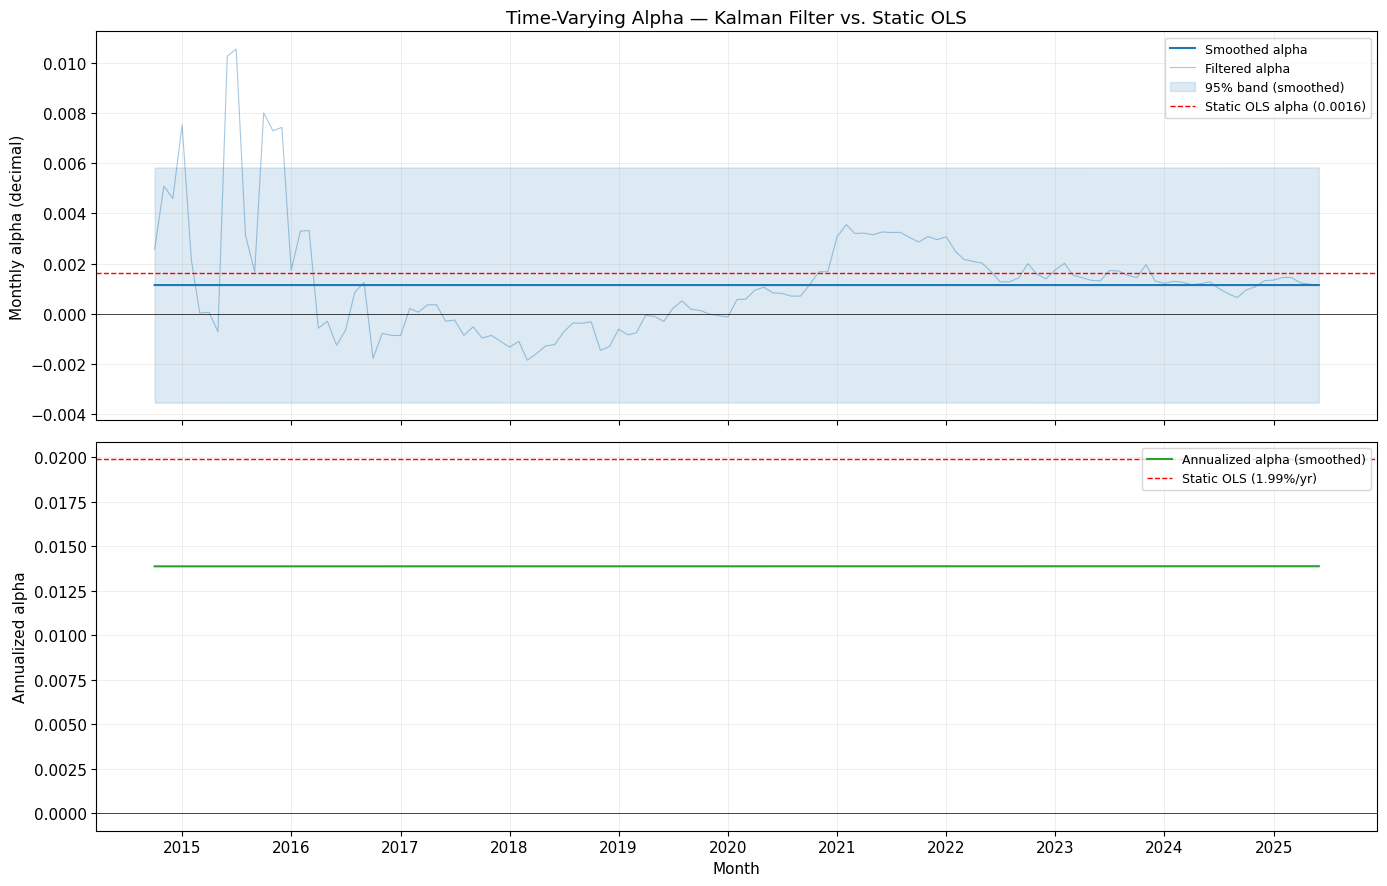

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# --- Panel A: Monthly alpha ---
ax = axes[0]
ax.plot(dates, df_smoothed["alpha"], label="Smoothed alpha", color="#1f77b4", lw=1.5)
ax.plot(dates, df_filtered["alpha"], label="Filtered alpha", color="#1f77b4", lw=0.8, alpha=0.4)
ax.fill_between(
    dates,
    df_smoothed["alpha"] - 2 * df_smoothed_se["alpha"],
    df_smoothed["alpha"] + 2 * df_smoothed_se["alpha"],
    alpha=0.15, color="#1f77b4", label="95% band (smoothed)",
)
ax.axhline(0, color="black", lw=0.5)
ax.axhline(ols_alpha_monthly, color="red", ls="--", lw=1, label=f"Static OLS alpha ({ols_alpha_monthly:.4f})")
ax.set_ylabel("Monthly alpha (decimal)")
ax.set_title("Time-Varying Alpha — Kalman Filter vs. Static OLS")
ax.legend(loc="upper right", fontsize=9)

# --- Panel B: Annualized alpha ---
ax = axes[1]
annual_alpha_smoothed = (1 + df_smoothed["alpha"]) ** 12 - 1
ax.plot(dates, annual_alpha_smoothed, color="#2ca02c", lw=1.5, label="Annualized alpha (smoothed)")
ax.axhline(0, color="black", lw=0.5)
ax.axhline(ols_alpha_annual, color="red", ls="--", lw=1, label=f"Static OLS ({ols_alpha_annual:.2%}/yr)")
ax.set_ylabel("Annualized alpha")
ax.set_xlabel("Month")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

## 6. Time-Varying Betas

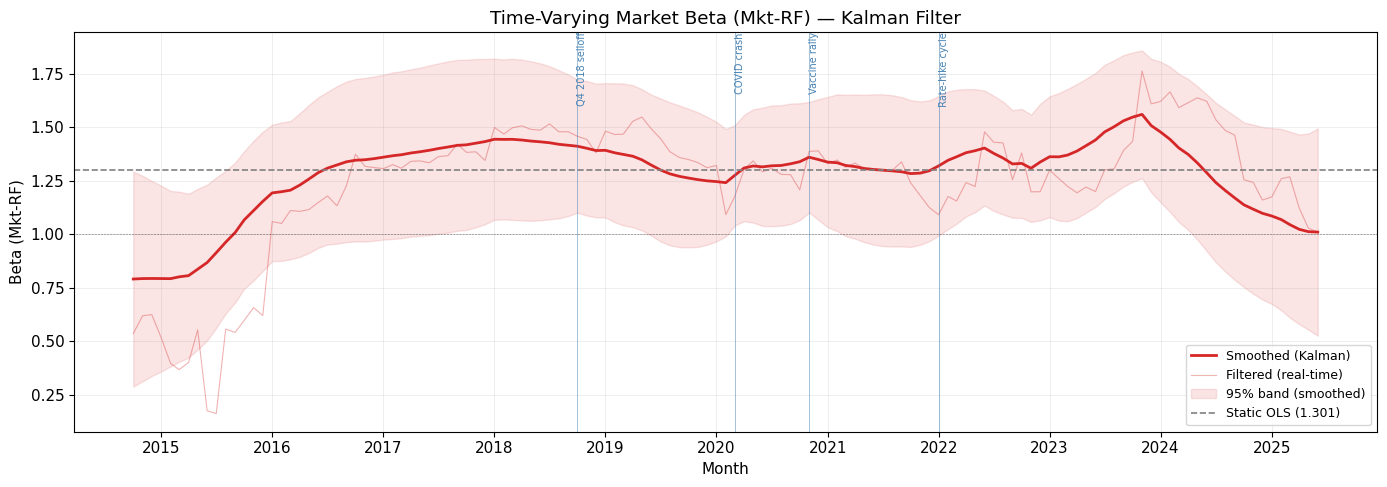

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates, df_smoothed["Mkt_RF"], color="#d62728", lw=2, label="Smoothed (Kalman)")
ax.plot(dates, df_filtered["Mkt_RF"], color="#d62728", lw=0.8, alpha=0.35, label="Filtered (real-time)")
ax.fill_between(
    dates,
    df_smoothed["Mkt_RF"] - 2 * df_smoothed_se["Mkt_RF"],
    df_smoothed["Mkt_RF"] + 2 * df_smoothed_se["Mkt_RF"],
    alpha=0.12, color="#d62728", label="95% band (smoothed)",
)
ax.axhline(ols_model.params[1], color="gray", ls="--", lw=1.2,
           label=f"Static OLS ({ols_model.params[1]:.3f})")
ax.axhline(1.0, color="black", lw=0.4, ls=":")

# Key events
for date_str, label in events.items():
    dt = pd.Timestamp(date_str)
    if dt in dates:
        ax.axvline(dt, color="steelblue", lw=0.7, alpha=0.5)
        ax.text(dt, ax.get_ylim()[1], f" {label}", fontsize=7, rotation=90,
                va="top", ha="left", color="steelblue")

ax.set_title("Time-Varying Market Beta (Mkt-RF) — Kalman Filter")
ax.set_ylabel("Beta (Mkt-RF)")
ax.set_xlabel("Month")
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

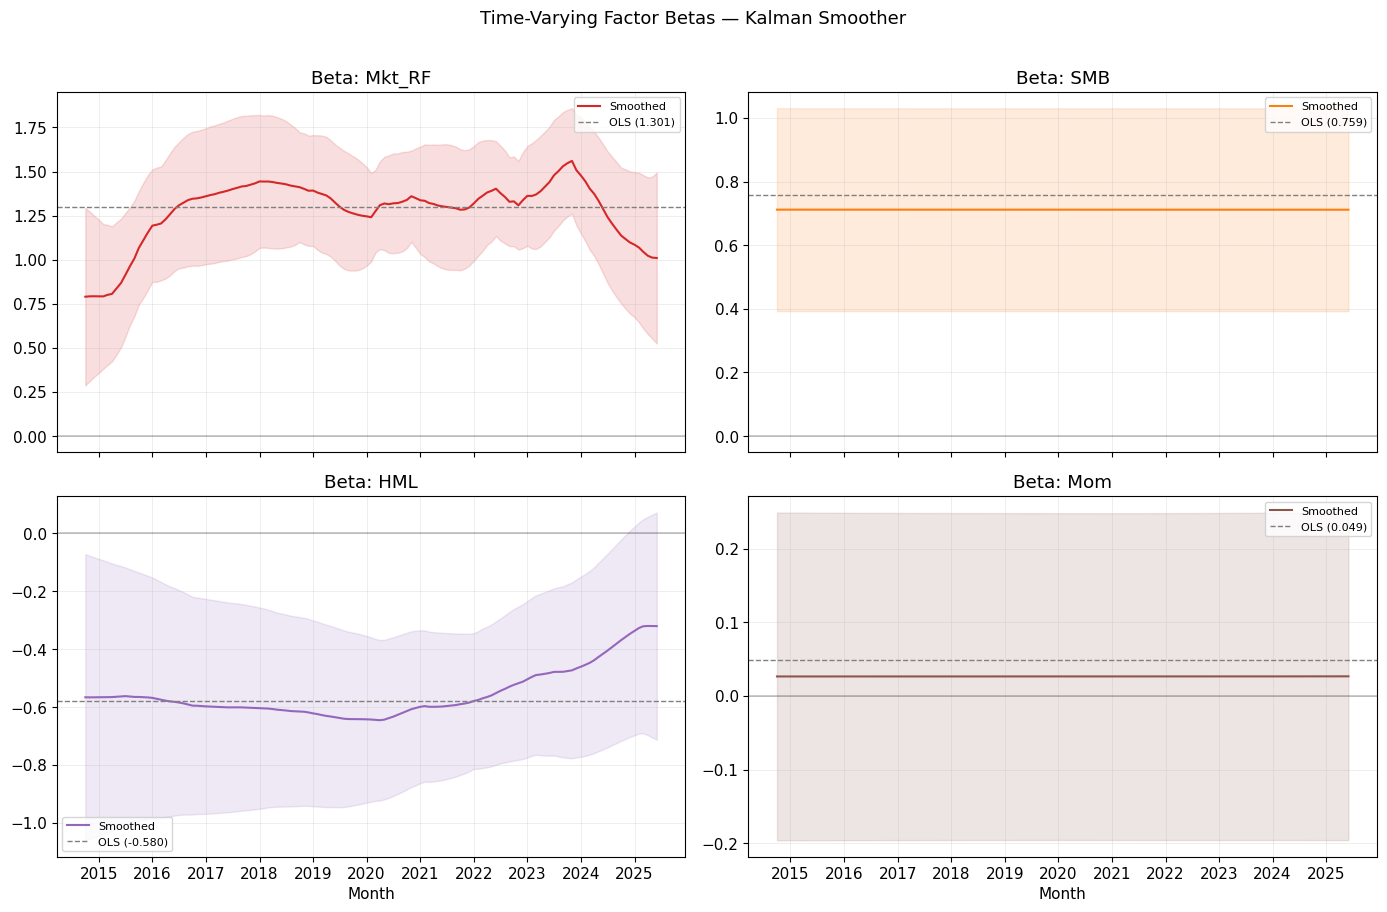

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

colors = ["#d62728", "#ff7f0e", "#9467bd", "#8c564b"]

for ax, factor, color in zip(axes.flat, FACTOR_COLS, colors):
    # Smoothed path
    ax.plot(dates, df_smoothed[factor], color=color, lw=1.5, label="Smoothed")
    # 95% band
    ax.fill_between(
        dates,
        df_smoothed[factor] - 2 * df_smoothed_se[factor],
        df_smoothed[factor] + 2 * df_smoothed_se[factor],
        alpha=0.15, color=color,
    )
    # Static OLS reference
    idx = 1 + FACTOR_COLS.index(factor)
    ax.axhline(ols_model.params[idx], color="gray", ls="--", lw=1,
               label=f"OLS ({ols_model.params[idx]:.3f})")
    ax.axhline(0, color="black", lw=0.3)
    ax.set_title(f"Beta: {factor}")
    ax.legend(fontsize=8, loc="best")

axes[1, 0].set_xlabel("Month")
axes[1, 1].set_xlabel("Month")
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Time-Varying Factor Betas — Kalman Smoother", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 7. Diagnostics

Standardized one-step-ahead prediction errors should be approximately i.i.d. N(0,1)
if the model is well-specified.

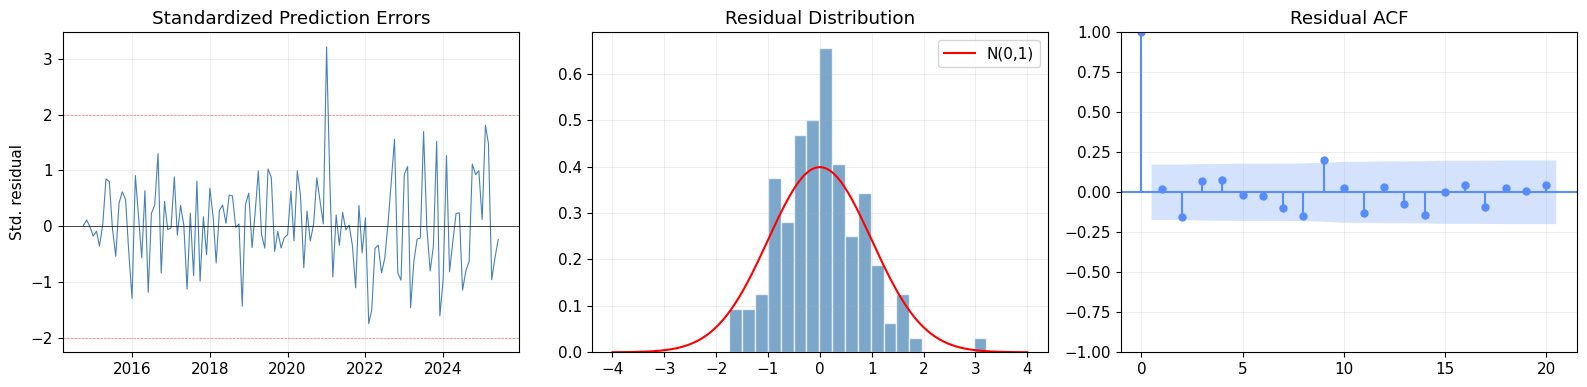

Ljung-Box test (H0: no serial correlation):
      lb_stat  lb_pvalue
6    4.967868   0.547941
12  17.756751   0.123278


In [10]:
# One-step-ahead predictions from the filter
y_pred = np.array([
    obs_matrices[t] @ filtered_means[t]
    for t in range(n_obs)
]).flatten()

residuals = y - y_pred

# Prediction variance at each step
pred_var = np.array([
    (obs_matrices[t] @ filtered_covs[t] @ obs_matrices[t].T + kf.observation_covariance)[0, 0]
    for t in range(n_obs)
])
std_residuals = residuals / np.sqrt(pred_var)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Standardized residuals over time
axes[0].plot(dates, std_residuals, lw=0.8, color="steelblue")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].axhline(2, color="red", ls="--", lw=0.5, alpha=0.5)
axes[0].axhline(-2, color="red", ls="--", lw=0.5, alpha=0.5)
axes[0].set_title("Standardized Prediction Errors")
axes[0].set_ylabel("Std. residual")

# Histogram
axes[1].hist(std_residuals, bins=20, density=True, alpha=0.7, color="steelblue", edgecolor="white")
xg = np.linspace(-4, 4, 200)
axes[1].plot(xg, 1/np.sqrt(2*np.pi) * np.exp(-xg**2/2), "r-", lw=1.5, label="N(0,1)")
axes[1].set_title("Residual Distribution")
axes[1].legend()

# ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_residuals, ax=axes[2], lags=20, alpha=0.05)
axes[2].set_title("Residual ACF")

fig.tight_layout()
plt.show()

# Ljung-Box test for serial correlation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(std_residuals, lags=[6, 12], return_df=True)
print("Ljung-Box test (H0: no serial correlation):")
print(lb.to_string())

## 8. Model Comparison: Static OLS vs. Kalman

In [11]:
# Log-likelihood from the Kalman filter
kf_loglik = kf.loglikelihood(observations)

# OLS log-likelihood
ols_loglik = ols_model.llf

# Number of free parameters
# OLS: n_states (const + betas) + 1 (sigma^2)
ols_k = n_states + 1
# Kalman: diagonal Q has n_states free params + R has 1
kf_k = n_states + 1

# AIC = -2*loglik + 2*k
ols_aic = -2 * ols_loglik + 2 * ols_k
kf_aic = -2 * kf_loglik + 2 * kf_k

# BIC = -2*loglik + k*log(n)
ols_bic = -2 * ols_loglik + ols_k * np.log(n_obs)
kf_bic = -2 * kf_loglik + kf_k * np.log(n_obs)

comparison = pd.DataFrame({
    "Model": ["Static OLS (4-factor)", "TVP Kalman (4-factor)"],
    "Log-Likelihood": [ols_loglik, kf_loglik],
    "Free Params": [ols_k, kf_k],
    "AIC": [ols_aic, kf_aic],
    "BIC": [ols_bic, kf_bic],
}).set_index("Model")

print(comparison.round(2).to_string())
print(f"\nLR test statistic: {2 * (kf_loglik - ols_loglik):.2f}")
print(f"Additional params in Kalman: {kf_k - ols_k}")

                       Log-Likelihood  Free Params     AIC     BIC
Model                                                             
Static OLS (4-factor)          293.56            6 -575.11 -557.95
TVP Kalman (4-factor)          279.25            6 -546.51 -529.35

LR test statistic: -28.60
Additional params in Kalman: 0


In [12]:
# --- Summary statistics of time-varying parameters ---
summary = pd.DataFrame({
    "OLS_estimate": ols_model.params,
    "Kalman_mean": df_smoothed.mean(),
    "Kalman_std": df_smoothed.std(),
    "Kalman_min": df_smoothed.min(),
    "Kalman_max": df_smoothed.max(),
}, index=["alpha"] + FACTOR_COLS)

print("\nParameter comparison (smoothed Kalman vs. static OLS):")
print(summary.round(4).to_string())


Parameter comparison (smoothed Kalman vs. static OLS):
        OLS_estimate  Kalman_mean  Kalman_std  Kalman_min  Kalman_max
alpha         0.0016       0.0011      0.0000      0.0011      0.0011
Mkt_RF        1.3011       1.2805      0.1771      0.7903      1.5604
SMB           0.7585       0.7117      0.0001      0.7116      0.7118
HML          -0.5804      -0.5543      0.0843     -0.6453     -0.3196
Mom           0.0492       0.0264      0.0001      0.0263      0.0266


## 9. Event Annotation — Alpha Around Key Periods

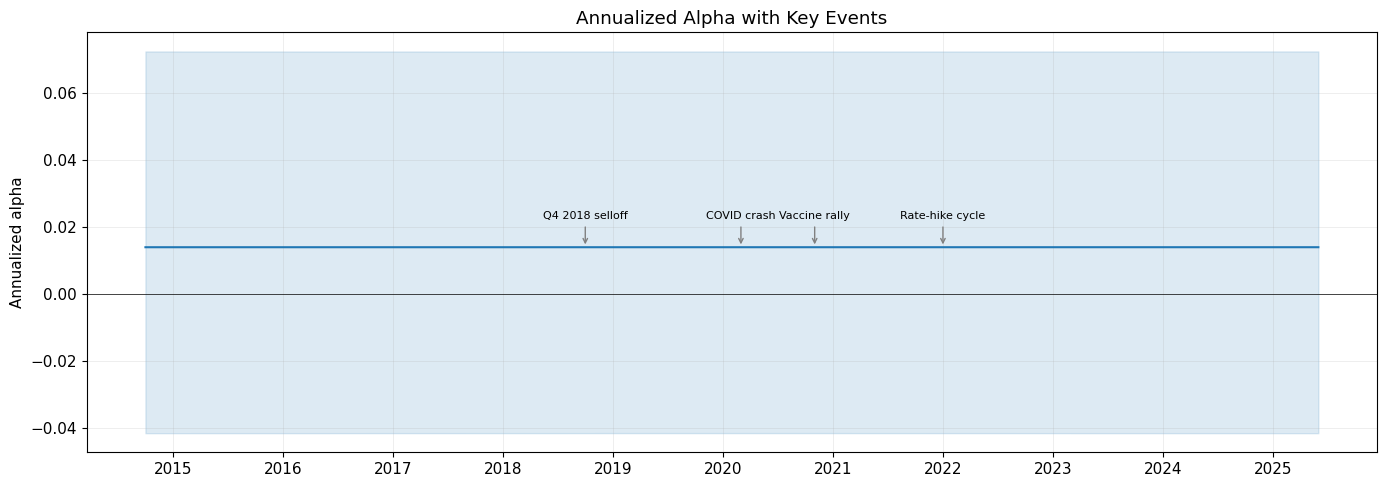

In [13]:
events = {
    "2018-10": "Q4 2018 selloff",
    "2020-03": "COVID crash",
    "2020-11": "Vaccine rally",
    "2022-01": "Rate-hike cycle",
}

fig, ax = plt.subplots(figsize=(14, 5))
annual_alpha = (1 + df_smoothed["alpha"]) ** 12 - 1
ax.plot(dates, annual_alpha, color="#1f77b4", lw=1.5)
ax.fill_between(
    dates,
    ((1 + df_smoothed["alpha"] - 2 * df_smoothed_se["alpha"]) ** 12 - 1),
    ((1 + df_smoothed["alpha"] + 2 * df_smoothed_se["alpha"]) ** 12 - 1),
    alpha=0.15, color="#1f77b4",
)
ax.axhline(0, color="black", lw=0.5)

for date_str, label in events.items():
    dt = pd.Timestamp(date_str)
    if dt in dates:
        val = annual_alpha.loc[dt]
        ax.annotate(
            label, xy=(dt, val), xytext=(0, 20),
            textcoords="offset points", fontsize=8,
            arrowprops=dict(arrowstyle="->", color="gray"),
            ha="center",
        )

ax.set_title("Annualized Alpha with Key Events")
ax.set_ylabel("Annualized alpha")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

## 10. Export Results

In [14]:
# Combine smoothed states + standard errors into one export
export = df_smoothed.copy()
for col in state_names:
    export[f"{col}_se"] = df_smoothed_se[col]

export["annualized_alpha"] = (1 + export["alpha"]) ** 12 - 1
export["excess_ret"] = y
export["fitted"] = y_pred
export["residual"] = residuals

export.to_csv("tvp_kalman_results.csv")
print(f"Exported {len(export)} rows to kalman/tvp_kalman_results.csv")
export.head()

Exported 129 rows to kalman/tvp_kalman_results.csv


,alpha,Mkt_RF,SMB,HML,Mom,alpha_se,Mkt_RF_se,SMB_se,HML_se,Mom_se,annualized_alpha,excess_ret,fitted,residual
month,,,,,,,,,,,,,,
2014-10-01,0.001148,0.790312,0.711767,-0.566035,0.026442,0.002343,0.251535,0.159459,0.247142,0.111133,0.01386,-0.0142,-0.014644,0.000444
2014-11-01,0.001148,0.792363,0.711767,-0.566279,0.026442,0.002343,0.240213,0.159453,0.244435,0.111125,0.01386,0.0142,0.010868,0.003332
2014-12-01,0.001148,0.792848,0.711768,-0.566077,0.026441,0.002343,0.228159,0.159449,0.241769,0.111116,0.01386,-0.0073,-0.007036,-0.000264
2015-01-01,0.001148,0.792450,0.711769,-0.565913,0.026440,0.002343,0.217263,0.159444,0.239067,0.111108,0.01386,0.0023,0.007972,-0.005672
2015-02-01,0.001148,0.792046,0.711770,-0.565754,0.026440,0.002343,0.205067,0.159439,0.236369,0.111099,0.01386,0.0182,0.021085,-0.002885


In [15]:
# Rolling regression uses the same modeling frame as Model 1.
df_roll = df_model

## 11. Rolling-Window OLS — A Middle Ground

Static OLS assumes the betas are *constant*; the Kalman filter lets every beta
drift *each* month. A **rolling-window OLS** sits between the two: the betas are
re-estimated on a trailing fixed window (24 and 36 months here). The coefficient
at month *t* uses the window **ending at** *t*, so it lines up directly with the
Kalman *smoothed* path. We also compute a true out-of-sample one-step-ahead
prediction (fit on months `[t-w, t-1]`, predict `t`) — the fair analogue of the
Kalman *filtered* one-step forecast.

In [16]:
from rolling_regression import rolling_ols, rolling_one_step_pred, rolling_summary

FACTORS_ROLL = FACTOR_COLS
WINDOWS = [24, 36]
roll = {w: rolling_ols(df_roll, FACTORS_ROLL, w) for w in WINDOWS}
roll_pred = {w: rolling_one_step_pred(df_roll, FACTORS_ROLL, w) for w in WINDOWS}

for w in WINDOWS:
    first = roll[w].dropna(subset=["alpha"]).index[0]
    print(f"Rolling-{w}m: {roll[w]['alpha'].notna().sum()} estimates "
          f"({first:%Y-%m} onward)")

Rolling-24m: 106 estimates (2016-09 onward)
Rolling-36m: 94 estimates (2017-09 onward)


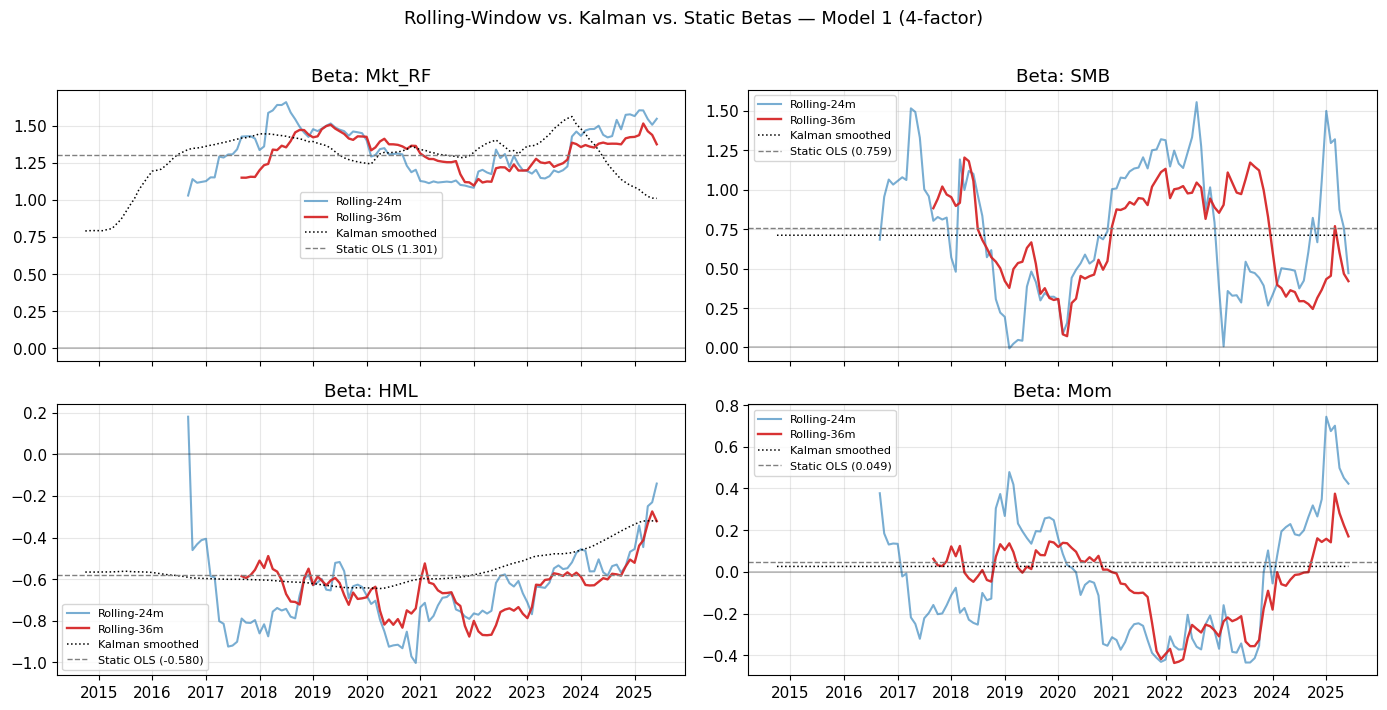

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
wstyle = {24: dict(color="#1f77b4", lw=1.5, alpha=0.6),
          36: dict(color="#d62728", lw=1.7, alpha=0.95)}

for ax, factor in zip(axes.flat, FACTORS_ROLL):
    idx = 1 + FACTORS_ROLL.index(factor)
    for w in WINDOWS:
        ax.plot(roll[w].index, roll[w][factor], label=f"Rolling-{w}m", **wstyle[w])
    ax.plot(df_smoothed.index, df_smoothed[factor], color="black", lw=1.1,
            ls=":", label="Kalman smoothed")
    ax.axhline(ols_model.params[idx], color="gray", ls="--", lw=1,
               label=f"Static OLS ({ols_model.params[idx]:.3f})")
    ax.axhline(0, color="black", lw=0.3)
    ax.set_title(f"Beta: {factor}")
    ax.legend(fontsize=8, loc="best")

# hide any unused axes
for ax in axes.flat[len(FACTORS_ROLL):]:
    ax.set_visible(False)
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Rolling-Window vs. Kalman vs. Static Betas — Model 1 (4-factor)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

In [18]:
for w in WINDOWS:
    s = rolling_summary(roll[w], ols_model.params, FACTORS_ROLL)
    print(f"\nRolling-{w}m vs. static OLS:")
    print(s.round(4).to_string())


Rolling-24m vs. static OLS:
        OLS_estimate  Rolling_mean  Rolling_std  Rolling_min  Rolling_max
alpha         0.0016        0.0002       0.0058      -0.0092       0.0152
Mkt_RF        1.3011        1.3348       0.1658       1.0288       1.6572
SMB           0.7585        0.7467       0.4021      -0.0059       1.5557
HML          -0.5804       -0.6532       0.1804      -1.0034       0.1813
Mom           0.0492       -0.0470       0.2902      -0.4343       0.7441

Rolling-36m vs. static OLS:
        OLS_estimate  Rolling_mean  Rolling_std  Rolling_min  Rolling_max
alpha         0.0016        0.0012       0.0046      -0.0077       0.0112
Mkt_RF        1.3011        1.3194       0.1090       1.0957       1.5136
SMB           0.7585        0.7047       0.3028       0.0716       1.2043
HML          -0.5804       -0.6474       0.1192      -0.8764      -0.2744
Mom           0.0492       -0.0528       0.1833      -0.4364       0.3751


In [19]:
# One-step-ahead out-of-sample accuracy vs. the Kalman filter and static OLS.
def _rmse(r):
    r = np.asarray(r, float)
    r = r[~np.isnan(r)]
    return np.sqrt((r ** 2).mean())

_y = df_roll["excess_ret"].values
_tss = np.var(_y) * len(_y)
rows = [
    ("Static OLS (in-sample)", _rmse(ols_model.resid), ols_model.rsquared),
    ("TVP Kalman (1-step)", _rmse(residuals),
     1 - np.nansum(np.asarray(residuals) ** 2) / _tss),
]
for w in WINDOWS:
    r = roll_pred[w]["residual"].values
    m = ~np.isnan(r)
    rows.append((f"Rolling-{w}m (1-step OOS)", _rmse(r),
                 1 - np.nansum(r[m] ** 2) / (np.var(_y[m]) * m.sum())))

pred_compare = pd.DataFrame(rows, columns=["Model", "RMSE", "R2"]).set_index("Model")
print(pred_compare.round(4).to_string())

                            RMSE      R2
Model                                   
Static OLS (in-sample)    0.0249  0.8446
TVP Kalman (1-step)       0.0202  0.8971
Rolling-24m (1-step OOS)  0.0286  0.8169
Rolling-36m (1-step OOS)  0.0281  0.8369


In [20]:
rolling_export = []
for w in WINDOWS:
    e = roll[w].copy()
    e.insert(0, "window", w)
    e["fitted_oos"] = roll_pred[w]["fitted"]
    e["residual_oos"] = roll_pred[w]["residual"]
    e["excess_ret"] = df_roll["excess_ret"]
    e["annualized_alpha"] = (1 + e["alpha"]) ** 12 - 1
    rolling_export.append(e)
rolling_export = pd.concat(rolling_export)
rolling_export.to_csv("rolling_regression_results.csv")
print(f"Exported {len(rolling_export)} rows to kalman/rolling_regression_results.csv")
rolling_export.dropna(subset=["alpha"]).head()

Exported 258 rows to kalman/rolling_regression_results.csv


,window,alpha,Mkt_RF,SMB,HML,Mom,alpha_se,Mkt_RF_se,SMB_se,HML_se,Mom_se,r2,nobs,fitted_oos,residual_oos,excess_ret,annualized_alpha
month,,,,,,,,,,,,,,,,,
2016-09-01,24,0.001380,1.028770,0.683523,0.181251,0.377192,0.006319,0.187753,0.415632,0.622473,0.389075,0.677008,24.0,NaN,NaN,0.0762,0.016692
2016-10-01,24,-0.002903,1.139088,0.955309,-0.460477,0.184499,0.006541,0.189242,0.422686,0.477404,0.387666,0.682477,24.0,-0.008789,-0.063211,-0.0720,-0.034279
2016-11-01,24,-0.003677,1.114718,1.064949,-0.432627,0.131416,0.006396,0.174566,0.439972,0.471094,0.364880,0.701325,24.0,-0.050151,0.012651,-0.0375,-0.043244
2016-12-01,24,-0.003356,1.120079,1.032992,-0.412429,0.136228,0.006282,0.175615,0.436762,0.468225,0.365345,0.700371,24.0,0.006583,0.008817,0.0154,-0.039542
2017-01-01,24,-0.003536,1.125810,1.055984,-0.405950,0.134720,0.006403,0.168209,0.459579,0.454640,0.361376,0.714958,24.0,0.051384,0.004416,0.0558,-0.041621
